In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")


In [2]:
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values>0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [3]:
missing_percentage = (
    train_df.isnull().sum() / len(train_df)
) * 100

missing_percentage.sort_values(
    ascending = False
).head(20)




PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

In [4]:
train_df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [5]:
categorical_colums = train_df.select_dtypes(
    include=["object"]
).columns

len(categorical_colums)

43

In [6]:
# Clasificamos las columnas según el porcentaje de valores faltantes
# Porque no todas las columnas con datos vacíos se tratan igual
#
# Reglas iniciales:
# - Si una columna tiene más de 80% de valores nulos, puede ser candidata a eliminarse.
# - Si tiene pocos valores nulos, normalmente se puede imputar
# - "Imputar" significa rellenar valores faltantes usando una estrategia:
#   media, mediana, moda o una categoría como "None"

missing_percentage = (
    train_df.isnull().sum() / len(train_df)
) * 100

high_missing_columns = missing_percentage[
    missing_percentage > 80
].sort_values(ascending=False)

medium_missing_columns = missing_percentage[
    (missing_percentage > 20) & (missing_percentage <= 80)
].sort_values(ascending=False)

low_missing_columns = missing_percentage[
    (missing_percentage > 0) & (missing_percentage <= 20)
].sort_values(ascending=False)

print("Columnas con más de 80% de nulos:")
print(high_missing_columns)

print("\nColumnas con 20% a 80% de nulos:")
print(medium_missing_columns)

print("\nColumnas con menos de 20% de nulos:")
print(low_missing_columns)

Columnas con más de 80% de nulos:
PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
dtype: float64

Columnas con 20% a 80% de nulos:
MasVnrType     59.726027
FireplaceQu    47.260274
dtype: float64

Columnas con menos de 20% de nulos:
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageType       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtFinType1     2.534247
BsmtCond         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [7]:
columns_to_drop = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence"
]

columns_to_review = [
    "MasVnrType",
    "FireplaceQu"
]

columns_to_impute = [
    "LotFrontage",
    "GarageYrBlt",
    "GarageFinish",
    "GarageQual",
    "GarageType",
    "GarageCond",
    "BsmtFinType2",
    "BsmtExposure",
    "BsmtQual",
    "BsmtFinType1",
    "BsmtCond",
    "MasVnrArea",
    "Electrical"
]

print("Eliminar:", len(columns_to_drop))
print("Revisar:", len(columns_to_review))
print("Imputar:", len(columns_to_impute))

Eliminar: 4
Revisar: 2
Imputar: 13


In [8]:
# Calidad de la chimenea
train_df["FireplaceQu"].value_counts(dropna=False)

FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

In [9]:
# Masonry Veneer Type
train_df["MasVnrType"].value_counts(dropna=False) #cuenta los vacíos

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [10]:
# Cantidad de pies lineales de calle
# que tiene el terreno

# Ejemplo Casa A → 60 pies
train_df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [11]:
# Resumen de columnas numéricas
# Queremos saber:
# - cuántas columnas numéricas existen
# - cuáles tienen nulos
# - cuáles no tienen nulos

# Dame únicamente columnas numéricas
numeric_columns = train_df.select_dtypes(
    include=["int64", "float64"]
)

numeric_columns.isnull().sum().sort_values(
    ascending=False
)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
LotArea            0
MSSubClass         0
Id                 0
OverallCond        0
OverallQual        0
YearRemodAdd       0
YearBuilt          0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
BsmtFinSF1         0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
1stFlrSF           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [12]:

train_df[[
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea"
]].describe()

,LotFrontage,GarageYrBlt,MasVnrArea
count,1201.000000,1379.000000,1452.000000
mean,70.049958,1978.506164,103.685262
std,24.284752,24.689725,181.066207
min,21.000000,1900.000000,0.000000
25%,59.000000,1961.000000,0.000000
50%,69.000000,1980.000000,0.000000
75%,80.000000,2002.000000,166.000000
max,313.000000,2010.000000,1600.000000


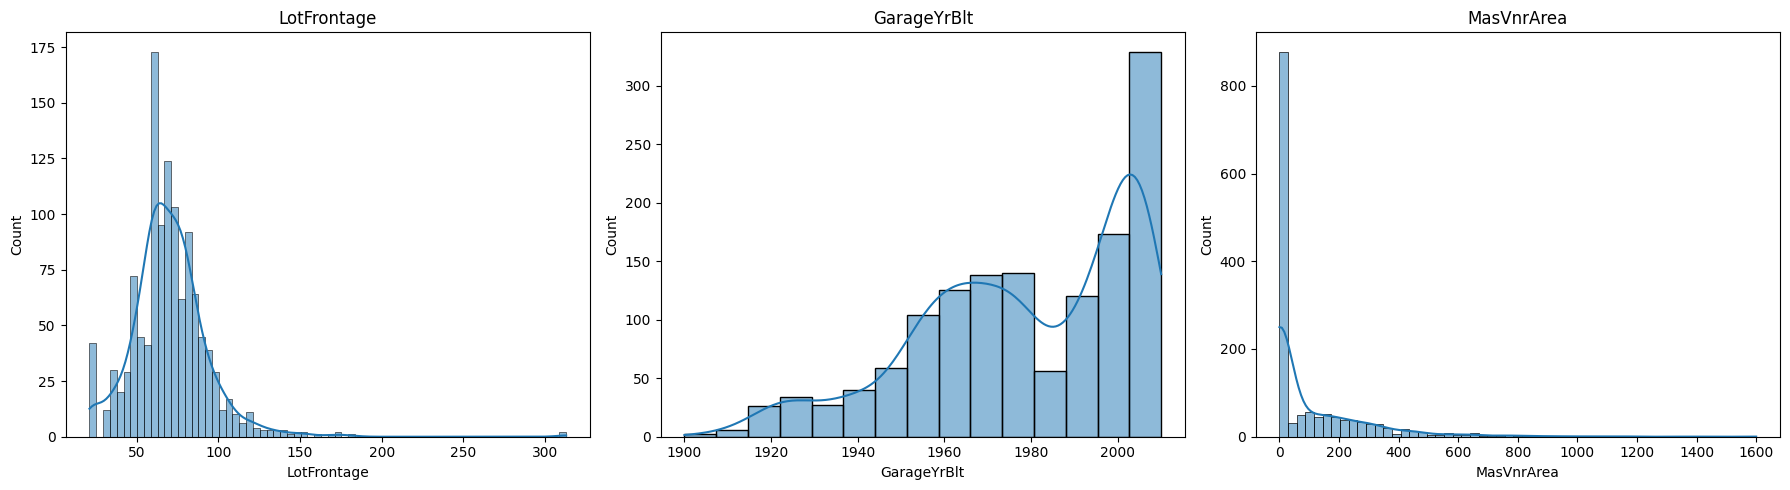

In [ ]:
fig, axes = plt.subplots( 1, 3, figsize=(18,5))

# kde La forma real de la distribución
sns.histplot(train_df["LotFrontage"], kde=True, ax= axes[0])
axes[0].set_title("LotFrontage")

sns.histplot(train_df["GarageYrBlt"], kde=True, ax= axes[1])
axes[1].set_title("GarageYrBlt")

sns.histplot(train_df["MasVnrArea"], kde=True, ax=  axes[2])
axes[2].set_title("MasVnrArea")


plt.tight_layout()
plt.show()


In [24]:
# Copia de trabajo para evitar modificar los datos originales
df = train_df.copy()

In [25]:
columns_to_drop = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence"
]

df = df.drop(columns= columns_to_drop)
print(df.shape)

(1460, 77)
